In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno #for missing value visualization

In [ ]:
# replace 'sales_data.csv' with your uploaded filename
df = pd.read_csv("/content/train.csv")

In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [ ]:
df.shape


(9800, 18)

In [ ]:
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df.info


<bound method DataFrame.info of       Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2017-152156   8/11/2017  11/11/2017    Second Class   
1          2  CA-2017-152156   8/11/2017  11/11/2017    Second Class   
2          3  CA-2017-138688   12/6/2017  16/06/2017    Second Class   
3          4  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
4          5  US-2016-108966  11/10/2016  18/10/2016  Standard Class   
...      ...             ...         ...         ...             ...   
9795    9796  CA-2017-125920  21/05/2017  28/05/2017  Standard Class   
9796    9797  CA-2016-128608   12/1/2016  17/01/2016  Standard Class   
9797    9798  CA-2016-128608   12/1/2016  17/01/2016  Standard Class   
9798    9799  CA-2016-128608   12/1/2016  17/01/2016  Standard Class   
9799    9800  CA-2016-128608   12/1/2016  17/01/2016  Standard Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United States        Henderson   
1       CG-12520       Claire Gute   Consumer  United States        Henderson   
2       DV-13045   Darrin Van Huff  Corporate  United States      Los Angeles   
3       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
4       SO-20335    Sean O'Donnell   Consumer  United States  Fort Lauderdale   
...          ...               ...        ...            ...              ...   
9795    SH-19975     Sally Hughsby  Corporate  United States          Chicago   
9796    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9797    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9798    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   
9799    CS-12490  Cindy Schnelling  Corporate  United States           Toledo   

           State  Postal Code   Region       Product ID         Category  \
0       Kentucky      42420.0    South  FUR-BO-10001798        Furniture   
1       Kentucky      42420.0    South  FUR-CH-10000454        Furniture   
2     California      90036.0     West  OFF-LA-10000240  Office Supplies   
3        Florida      33311.0    South  FUR-TA-10000577        Furniture   
4        Florida      33311.0    South  OFF-ST-10000760  Office Supplies   
...          ...          ...      ...              ...              ...   
9795    Illinois      60610.0  Central  OFF-BI-10003429  Office Supplies   
9796        Ohio      43615.0     East  OFF-AR-10001374  Office Supplies   
9797        Ohio      43615.0     East  TEC-PH-10004977       Technology   
9798        Ohio      43615.0     East  TEC-PH-10000912       Technology   
9799        Ohio      43615.0     East  TEC-AC-10000487       Technology   

     Sub-Category                                       Product Name     Sales  
0       Bookcases                  Bush Somerset Collection Bookcase  261.9600  
1          Chairs  Hon Deluxe Fabric Upholstered Stacking Chairs,...  731.9400  
2          Labels  Self-Adhesive Address Labels for Typewriters b...   14.6200  
3          Tables      Bretford CR4500 Series Slim Rectangular Table  957.5775  
4         Storage                     Eldon Fold 'N Roll Cart System   22.3680  
...           ...                                                ...       ...  
9795      Binders  Cardinal HOLDit! Binder Insert Strips,Extra St...    3.7980  
9796          Art           BIC Brite Liner Highlighters, Chisel Tip   10.3680  
9797       Phones                                        GE 30524EE4  235.1880  
9798       Phones           Anker 24W Portable Micro USB Car Charger   26.3760  
9799  Accessories                SanDisk Cruzer 4 GB USB Flash Drive   10.3840  

[9800 rows x 18 columns]>

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df.isnull().values.any()

np.True_

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
duplicate_counts = df.value_counts()

print(duplicate_counts[duplicate_counts > 1])

Series([], Name: count, dtype: int64)


In [ ]:
# 1. Check if any missing values exist in the whole DataFrame
print("Any missing values? :", df.isnull().values.any())

# 2. Count missing values column-wise
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Count total missing values in entire dataset
print("\nTotal missing values in dataset:", df.isnull().sum().sum())

# 4. Percentage of missing values per column
print("\nPercentage of missing values per column:")
print((df.isnull().sum() / len(df)) * 100)

# 5. Show only columns that have missing values
print("\nColumns with missing values only:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 6. Display rows that contain missing values (first 10 only for clarity)
print("\nFirst 10 rows with missing values:")
print(df[df.isnull().any(axis=1)].head(10))


Any missing values? : True

Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Total missing values in dataset: 11

Percentage of missing values per column:
Row ID           0.000000
Order ID         0.000000
Order Date       0.000000
Ship Date        0.000000
Ship Mode        0.000000
Customer ID      0.000000
Customer Name    0.000000
Segment          0.000000
Country          0.000000
City             0.000000
State            0.000000
Postal Code      0.112245
Region           0.000000
Product ID       0.000000
Category         0.000000
Sub-Category     0.000000
Product Name     0.000000
Sales            0.000000
dtype: float64

Columns w

In [ ]:
df.fillna({'Postal Code': 0}, inplace=True)


In [ ]:
print("Any missing values? :", df.isnull().values.any())

print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Count total missing values in entire dataset
print("\nTotal missing values in dataset:", df.isnull().sum().sum())

# 4. Percentage of missing values per column
print("\nPercentage of missing values per column:")
print((df.isnull().sum() / len(df)) * 100)

# 5. Show only columns that have missing values
print("\nColumns with missing values only:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 6. Display rows that contain missing values (first 10 only for clarity)
print("\nFirst 10 rows with missing values:")
print(df[df.isnull().any(axis=1)].head(10))


Any missing values? : False

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

Total missing values in dataset: 0

Percentage of missing values per column:
Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
dtype: float64

Columns with missing values only:
Series([], dtype: int64)

First 10 rows with missing values:
Empty DataFrame
Column

In [ ]:
print(df.describe())

            Row ID   Postal Code         Sales
count  9800.000000   9800.000000   9800.000000
mean   4900.500000  55211.280918    230.769059
std    2829.160653  32076.677954    626.651875
min       1.000000      0.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  57551.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


In [ ]:
print(df.describe(include=['object']))

              Order ID Order Date   Ship Date       Ship Mode Customer ID  \
count             9800       9800        9800            9800        9800   
unique            4922       1230        1326               4         793   
top     CA-2018-100111   5/9/2017  26/09/2018  Standard Class    WB-21850   
freq                14         38          34            5859          35   

        Customer Name   Segment        Country           City       State  \
count            9800      9800           9800           9800        9800   
unique            793         3              1            529          49   
top     William Brown  Consumer  United States  New York City  California   
freq               35      5101           9800            891        1946   

       Region       Product ID         Category Sub-Category     Product Name  
count    9800             9800             9800         9800             9800  
unique      4             1861                3           17        

In [ ]:
print(df['Category'].unique())

['Furniture' 'Office Supplies' 'Technology']


In [ ]:
print(df['Sub-Category'].unique())

['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [ ]:
df['City'].nunique()

529

In [ ]:
print(df['Country'].unique())

['United States']


In [ ]:
print(df['Customer ID'].nunique())

793


In [ ]:
print(df['Order Date'].nunique())

1230


In [ ]:
print(df['Ship Date'].nunique())

1326


In [ ]:
print(df['Ship Mode'].unique())

['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [ ]:
print(df['Customer Name'].nunique())

793


In [ ]:
print(df['Segment'].unique())

['Consumer' 'Corporate' 'Home Office']


In [ ]:
print(df['Region'].unique())

['South' 'West' 'Central' 'East']


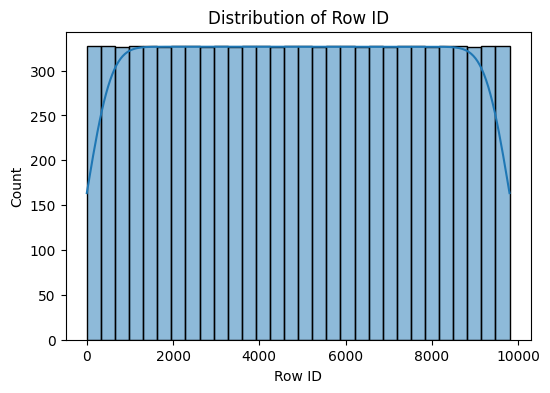

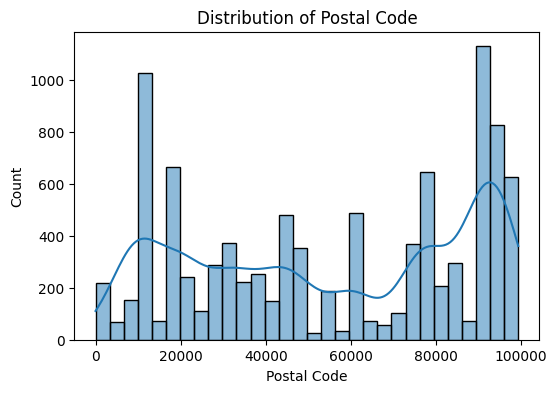

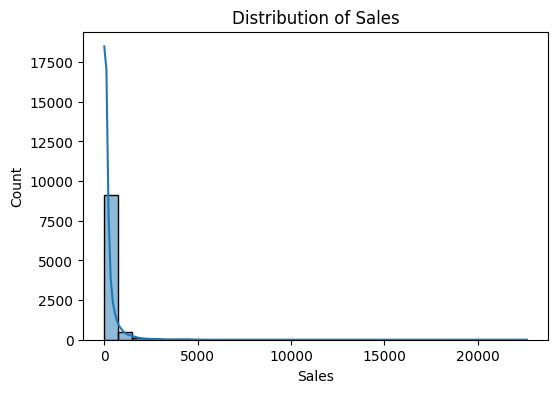

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

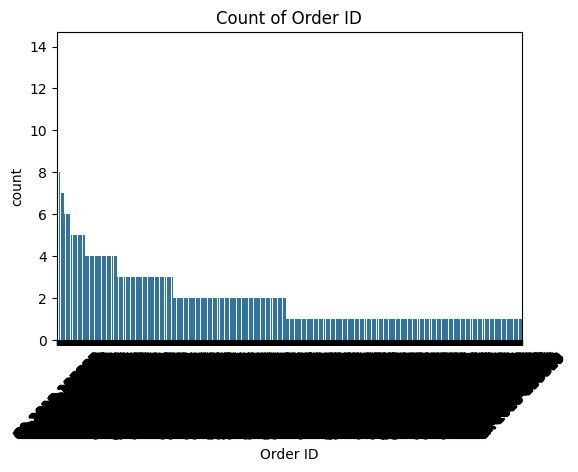

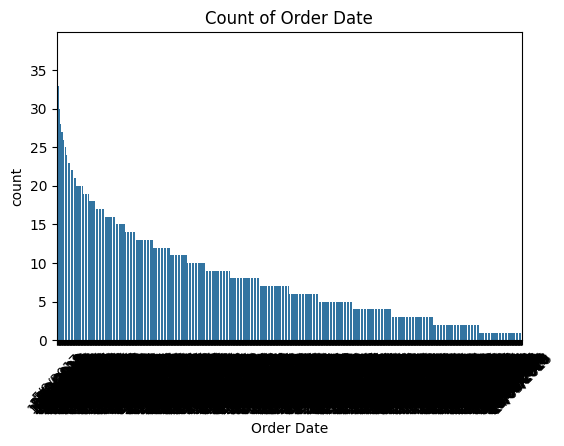

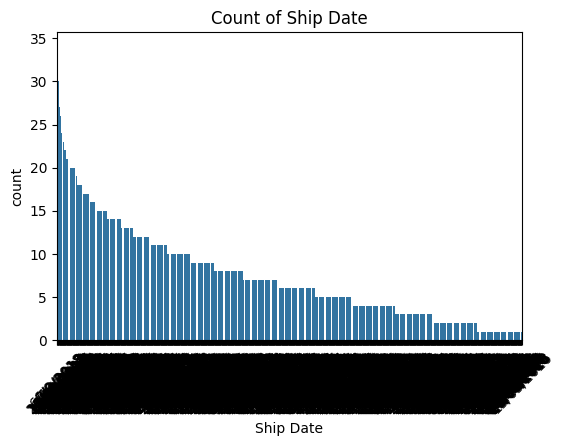

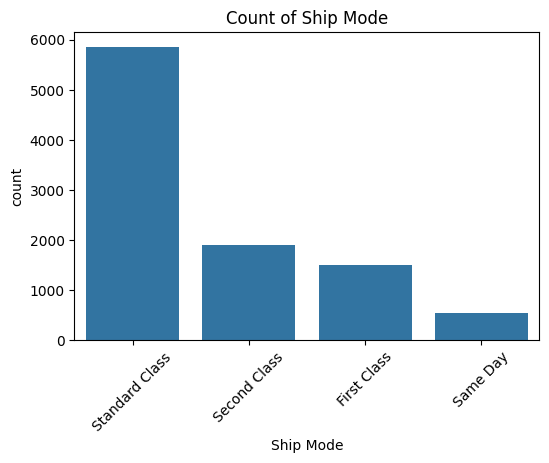

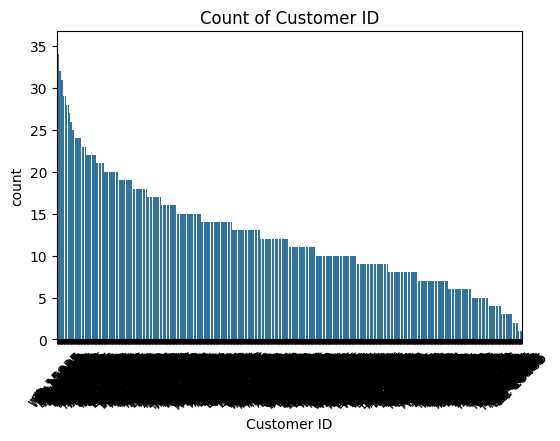

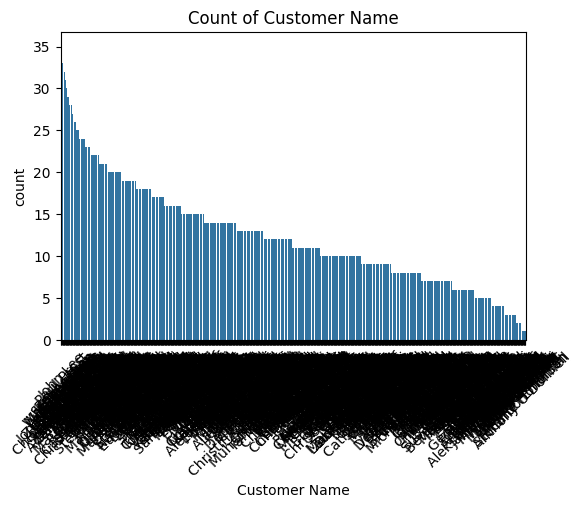

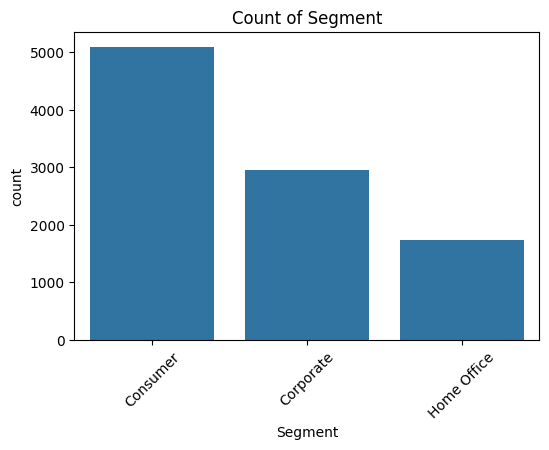

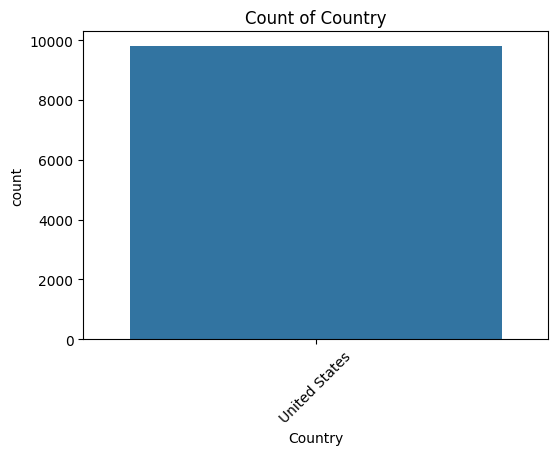

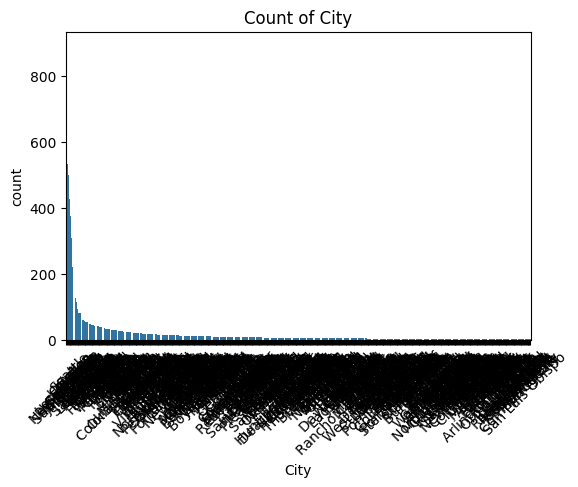

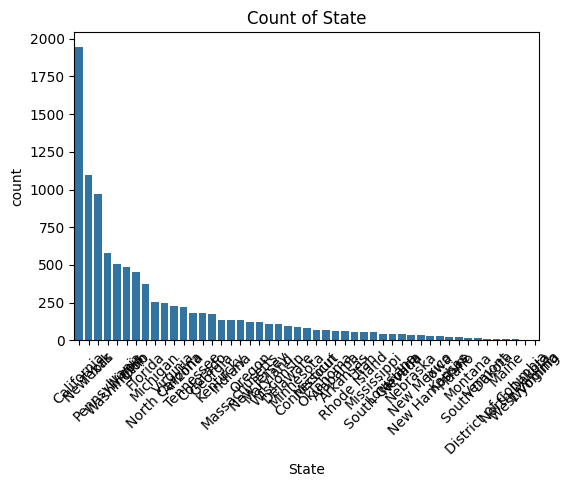

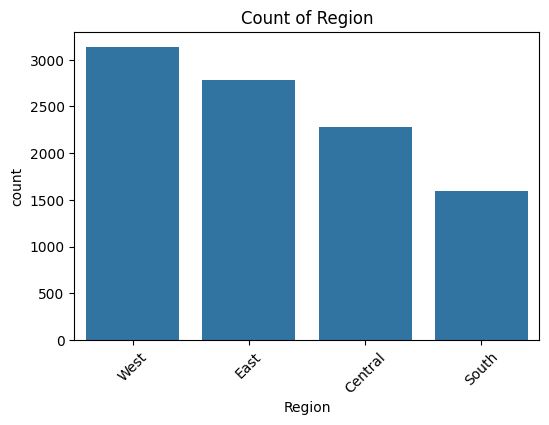

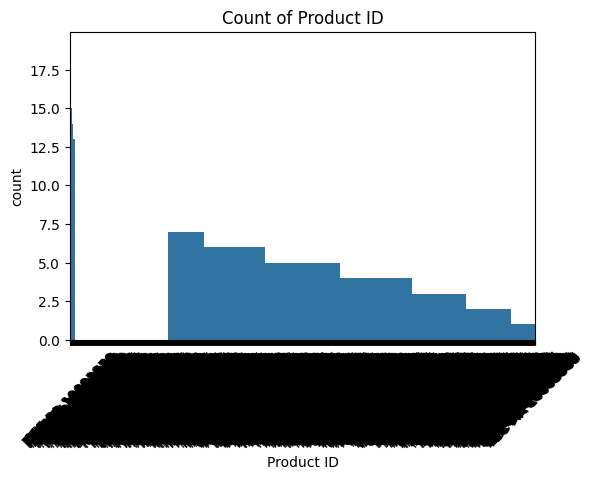

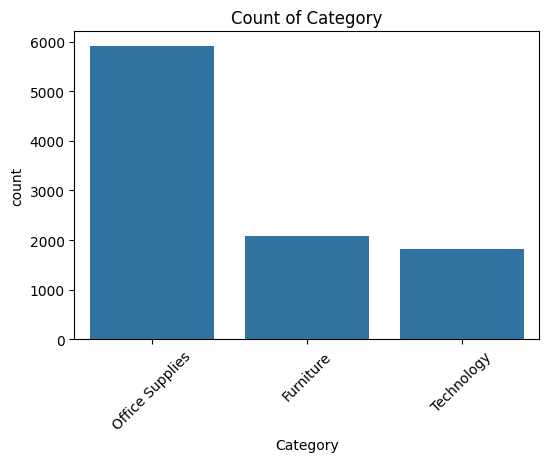

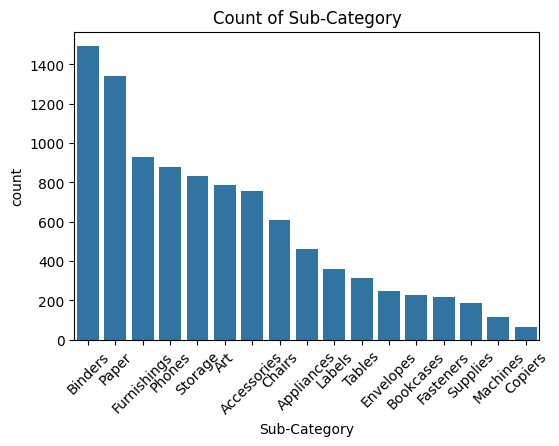

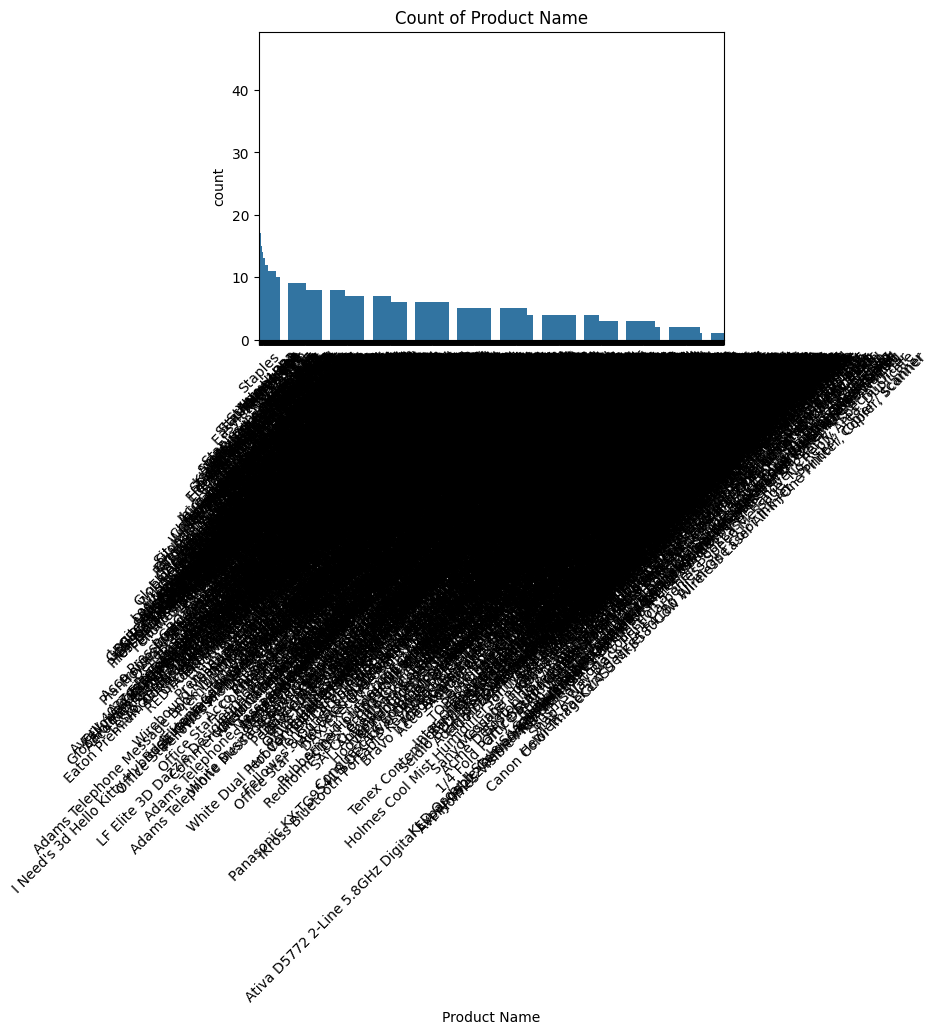

In [ ]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.title(f"Count of {col}")
    plt.xticks(rotation=45)
    plt.show()

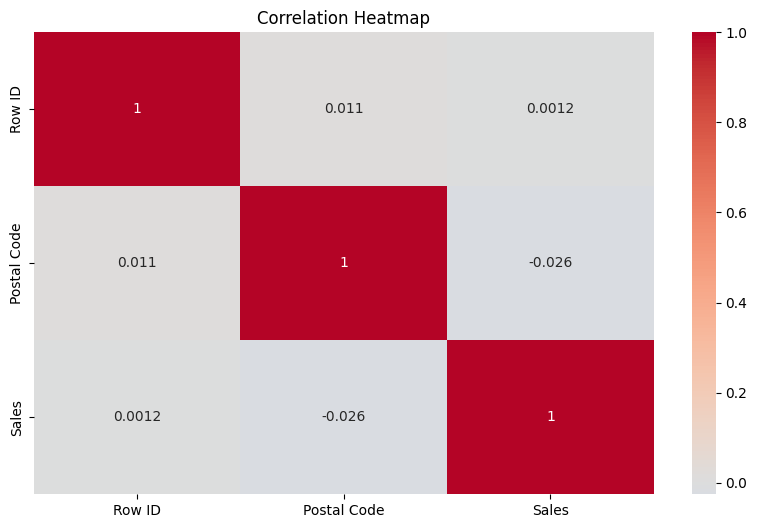

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


**FEATURE** **ENGINEERING**

**ENCODING CATEGORICAL VALUES**




In [ ]:
df = pd.get_dummies(df, columns=['Category'], drop_first=True)

In [ ]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID Sub-Categor

In [ ]:
df = pd.get_dummies(df, columns=['Ship Mode'], drop_first=True)


In [ ]:
df = pd.get_dummies(df, columns=['Segment'], drop_first=True)


In [ ]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date Customer ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016    SO-20335   

     Customer Name        Country             City       State  Postal Code  \
0      Claire Gute  United States        Henderson    Kentucky      42420.0   
1      Claire Gute  United States        Henderson    Kentucky      42420.0   
2  Darrin Van Huff  United States      Los Angeles  California      90036.0   
3   Sean O'Donnell  United States  Fort Lauderdale     Florida      33311.0   
4   Sean O'Donnell  United States  Fort Lauderdale     Florida      33311.0   

   ... Sub-Category                                       Product Name  \
0  ...    Bookcases                  Bush Somerset Collectio

In [ ]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Customer ID',
 'Customer Name',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Category_Office Supplies',
 'Category_Technology',
 'Ship Mode_Same Day',
 'Ship Mode_Second Class',
 'Ship Mode_Standard Class',
 'Segment_Corporate',
 'Segment_Home Office']

In [ ]:
df = pd.get_dummies(df, columns=['Region'], drop_first=True)


In [ ]:
print(df.head().to_string())


   Row ID        Order ID  Order Date   Ship Date Customer ID    Customer Name        Country             City       State  Postal Code       Product ID Sub-Category                                                 Product Name     Sales  Category_Office Supplies  Category_Technology  Ship Mode_Same Day  Ship Mode_Second Class  Ship Mode_Standard Class  Segment_Corporate  Segment_Home Office  Region_East  Region_South  Region_West
0       1  CA-2017-152156   8/11/2017  11/11/2017    CG-12520      Claire Gute  United States        Henderson    Kentucky      42420.0  FUR-BO-10001798    Bookcases                            Bush Somerset Collection Bookcase  261.9600                     False                False               False                    True                     False              False                False        False          True        False
1       2  CA-2017-152156   8/11/2017  11/11/2017    CG-12520      Claire Gute  United States        Henderson    Kentucky      4242

low cardinality (less unique values) - columns are encoded.

now moving on to enode high cardinalities.


In [ ]:
#dropping unecessary(non-informative data's) columns

In [ ]:
drop_cols = ["Row ID","Order ID","Customer ID","City","Postal Code","Customer Name","Product ID","Product Name"]

df = df.drop(columns=drop_cols)


In [ ]:
print("Remaining columns after dropping:")
print(df.columns)

Remaining columns after dropping:
Index(['Order Date', 'Ship Date', 'Country', 'State', 'Sub-Category', 'Sales',
       'Category_Office Supplies', 'Category_Technology', 'Ship Mode_Same Day',
       'Ship Mode_Second Class', 'Ship Mode_Standard Class',
       'Segment_Corporate', 'Segment_Home Office', 'Region_East',
       'Region_South', 'Region_West'],
      dtype='object')


In [ ]:
# Convert Order Date with dayfirst=True
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')

# Convert Ship Date too
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')


In [ ]:
# Convert Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Day'] = df['Order Date'].dt.day
df['DayOfWeek'] = df['Order Date'].dt.dayofweek  # 0=Mon, 6=Sun
df['Quarter'] = df['Order Date'].dt.quarter


In [ ]:
# Convert Ship Date
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculate shipping delay (in days)
df['ShippingDelay'] = (df['Ship Date'] - df['Order Date']).dt.days


In [ ]:
print(df.head().to_string())

  Order Date  Ship Date        Country       State Sub-Category     Sales  Category_Office Supplies  Category_Technology  Ship Mode_Same Day  Ship Mode_Second Class  Ship Mode_Standard Class  Segment_Corporate  Segment_Home Office  Region_East  Region_South  Region_West  Year  Month  Week  Day  DayOfWeek  Quarter  ShippingDelay
0 2017-11-08 2017-11-11  United States    Kentucky    Bookcases  261.9600                     False                False               False                    True                     False              False                False        False          True        False  2017     11    45    8          2        4              3
1 2017-11-08 2017-11-11  United States    Kentucky       Chairs  731.9400                     False                False               False                    True                     False              False                False        False          True        False  2017     11    45    8          2        4              3
2 2017-06-

In [ ]:
print(df.describe(include=['object']))

              Country       State Sub-Category
count            9800        9800         9800
unique              1          49           17
top     United States  California      Binders
freq             9800        1946         1492


Time series.


In [ ]:
# convert to datetime if not already
df['Order Date'] = pd.to_datetime(df['Order Date'])

# aggregate to weekly sales
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()

print(weekly_sales.head())


  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914


Train Text split


In [ ]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain sample:")
print(train.head())

print("\nTest sample:")
print(test.head())

Train shape: (157, 2)
Test shape: (52, 2)

Train sample:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914

Test sample:
    Order Date      Sales
157 2018-01-07   9060.984
158 2018-01-14   7332.659
159 2018-01-21  13698.768
160 2018-01-28   9476.086
161 2018-02-04   5776.328


In [ ]:
df = df.rename(columns={"Order Date": "ds", "Sales": "y"})


In [ ]:
weekly_sales['year'] = weekly_sales['Order Date'].dt.year
weekly_sales['month'] = weekly_sales['Order Date'].dt.month
weekly_sales['week'] = weekly_sales['Order Date'].dt.isocalendar().week


In [ ]:
from prophet import Prophet

# prepare data
df_prophet = weekly_sales.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

print(df_prophet.head())


          ds         y  year  month  week
0 2015-01-04   304.508  2015      1     1
1 2015-01-11  4619.108  2015      1     2
2 2015-01-18  4130.533  2015      1     3
3 2015-01-25  3092.544  2015      1     4
4 2015-02-01  2527.914  2015      2     5


In [ ]:
from prophet import Prophet

# Rename columns for Prophet
train_prophet = train.rename(columns={"Order Date": "ds", "Sales": "y"})
test_prophet = test.rename(columns={"Order Date": "ds", "Sales": "y"})


In [ ]:
# initialize Prophet
model = Prophet()

# fit the model on training data
model.fit(train_prophet)


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr72x9xhc/fypcic6n.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr72x9xhc/qvoa5qn_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=60200', 'data', 'file=/tmp/tmpr72x9xhc/fypcic6n.json', 'init=/tmp/tmpr72x9xhc/qvoa5qn_.json', 'output', 'file=/tmp/tmpr72x9xhc/prophet_modellx04pg7z/prophet_model-20250823154905.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
15:49:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:49:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# create future dataframe for prediction
future = model.make_future_dataframe(periods=len(test_prophet), freq='W')


In [ ]:
forecast = model.predict(future)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate MAE
mae = mean_absolute_error(results['y'], results['yhat'])

# Calculate RMSE manually
mse = mean_squared_error(results['y'], results['yhat'])
rmse = np.sqrt(mse)

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 4754.793426317594
RMSE: 6063.521273032966


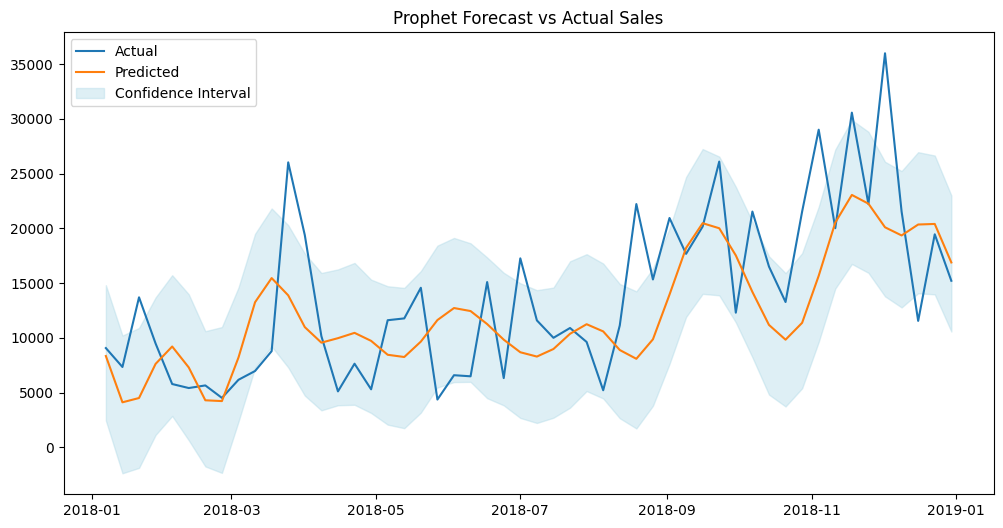

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(results['ds'], results['y'], label="Actual")
plt.plot(results['ds'], results['yhat'], label="Predicted")
plt.fill_between(results['ds'], results['yhat_lower'], results['yhat_upper'], color="lightblue", alpha=0.4, label="Confidence Interval")
plt.legend()
plt.title("Prophet Forecast vs Actual Sales")
plt.show()


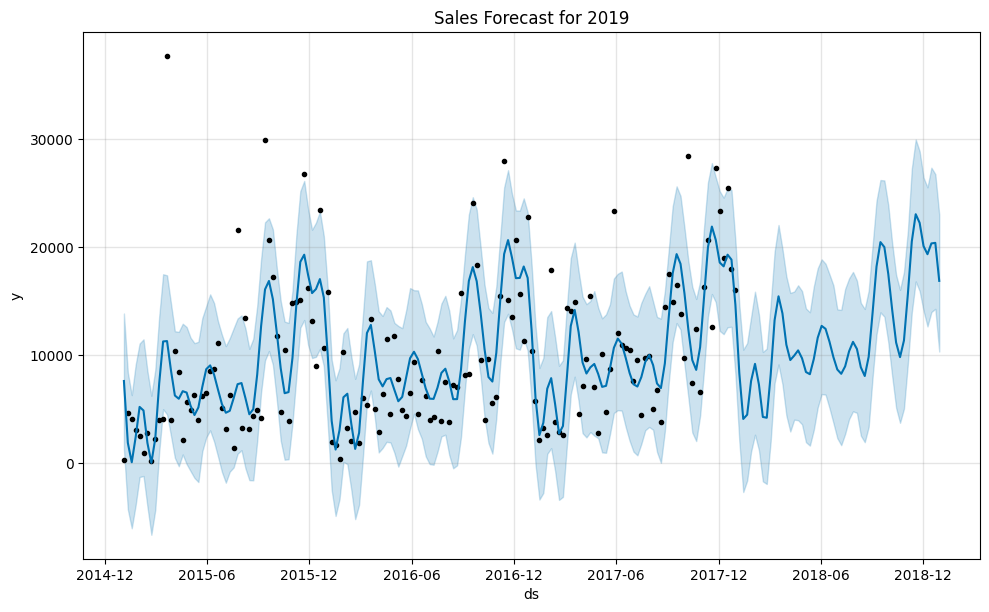

In [ ]:
future = model.make_future_dataframe(periods=52, freq='W')  # 52 weeks for 2019
forecast = model.predict(future)

model.plot(forecast)
plt.title("Sales Forecast for 2019")
plt.show()


In [ ]:
future_date = pd.DataFrame({'ds': ['2018-06-15']})  # change date here

# Make prediction
forecast = model.predict(future_date)

# Show predicted value
print("Predicted Sales on", future_date['ds'][0], ":", round(forecast['yhat'][0], 2))
print("Lower bound:", round(forecast['yhat_lower'][0], 2))
print("Upper bound:", round(forecast['yhat_upper'][0], 2))


Predicted Sales on 2018-06-15 : 11644.99
Lower bound: 4459.32
Upper bound: 17576.41


In [ ]:
# Use test set dates for forecasting
future = test_prophet[['ds']]   # only the dates
forecast = model.predict(future)

# Merge actual (test) with predicted
results = test_prophet.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='left'
)

# Show actual vs predicted
print(results.head(10))

# Evaluate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))

print("\nMAE:", mae)
print("RMSE:", rmse)


          ds           y          yhat   yhat_lower    yhat_upper
0 2018-01-07   9060.9840   8335.796655  1373.314628  14271.691247
1 2018-01-14   7332.6590   4105.543165 -2274.555990  10187.746566
2 2018-01-21  13698.7680   4497.251056 -1759.835389  10648.458355
3 2018-01-28   9476.0860   7617.594080  1207.261317  14046.569267
4 2018-02-04   5776.3280   9205.159974  2686.684846  15385.446469
5 2018-02-11   5409.7490   7291.324968  1164.584072  13375.257742
6 2018-02-18   5648.0154   4290.307291 -1943.620998  10516.143367
7 2018-02-25   4509.7520   4217.485602 -1964.216341  10927.025525
8 2018-03-04   6164.1820   8200.966978  1882.975049  14807.621620
9 2018-03-11   6965.4100  13251.549310  7585.023770  19417.396678

MAE: 4754.793426317594
RMSE: 6063.521273032966


In [ ]:
from prophet import Prophet

# Rename columns for Prophet
train_prophet = train.rename(columns={"Order Date": "ds", "Sales": "y"})
test_prophet = test.rename(columns={"Order Date": "ds", "Sales": "y"})

In [ ]:
# initialize Prophet
model = Prophet()

# fit the model on training data
model.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr72x9xhc/fl4drp0h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpr72x9xhc/s3phq8qu.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11342', 'data', 'file=/tmp/tmpr72x9xhc/fl4drp0h.json', 'init=/tmp/tmpr72x9xhc/s3phq8qu.json', 'output', 'file=/tmp/tmpr72x9xhc/prophet_modelp4n942fr/prophet_model-20250823164159.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
16:41:59 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:41:59 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# Use test set dates for forecasting
future = test_prophet[['ds']]   # only the dates
forecast = model.predict(future)

# Merge actual (test) with predicted
results = test_prophet.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds',
    how='left'
)

# Show actual vs predicted
print(results.head(10))

# Evaluate error metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(results['y'], results['yhat'])
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))

print("\nMAE:", mae)
print("RMSE:", rmse)

          ds           y          yhat   yhat_lower    yhat_upper
0 2018-01-07   9060.9840   8335.796655  1829.224081  14826.728016
1 2018-01-14   7332.6590   4105.543165 -2229.128262  10745.024269
2 2018-01-21  13698.7680   4497.251056 -1558.701080  10928.048190
3 2018-01-28   9476.0860   7617.594080  1520.191174  14008.068677
4 2018-02-04   5776.3280   9205.159974  2758.907902  15656.157039
5 2018-02-11   5409.7490   7291.324968  1460.975271  13428.703761
6 2018-02-18   5648.0154   4290.307291 -1936.079435  10737.663484
7 2018-02-25   4509.7520   4217.485602 -1843.118765  10502.964956
8 2018-03-04   6164.1820   8200.966978  2286.375139  14338.140778
9 2018-03-11   6965.4100  13251.549310  6778.702131  19279.686881

MAE: 4754.793426317594
RMSE: 6063.521273032966


In [ ]:
# Print actual and predicted values
print("Actual vs Predicted Sales (Test Set):")
print(results[['ds', 'y', 'yhat']].head().to_string())

Actual vs Predicted Sales (Test Set):
          ds          y         yhat
0 2018-01-07   9060.984  8335.796655
1 2018-01-14   7332.659  4105.543165
2 2018-01-21  13698.768  4497.251056
3 2018-01-28   9476.086  7617.594080
4 2018-02-04   5776.328  9205.159974
